In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [89]:
data = pd.read_csv("dirty_financial_transactions.csv")
print(data.isnull().sum())


Transaction_ID         301
Transaction_Date       279
Customer_ID            286
Product_Name             0
Quantity               275
Price                 1926
Payment_Method           0
Transaction_Status     942
dtype: int64


In [90]:
for col in data.columns:
    data[col] = data[col].replace(['ERROR', 'UNKNOWN'], np.nan)

In [91]:
data['Product_Name'].unique()
type=[    'Headphones',        'Coffee ',         'Tablet',            'Tab',
 'Coffee Machine',     'Smartphone',         'Laptop',      'Coffee Ma',
            'Cof',           'Smar',       'Coffee M',              'T',
         'Smartp',          'Headp',          'Smart',             'La',
           'Lapt',           'Tabl',              'L',              'C',
        'Smartph',            'Hea',           'Head',       'Smartpho',
          'Lapto',       'Headphon',          'Table',             'Co',
      'Headphone',     'Coffee Mac',             'Sm',         'Coffee',
         'Headph',              'S',    'Coffee Mach',      'Smartphon',
        'Headpho',  'Coffee Machin',           'Coff',            'Lap',
              'H',             'He',             'Ta',   'Coffee Machi',
          'Coffe',            'Sma']
dict={val:i for i,val in enumerate(type)}
print (dict)

data['Product_Name']=data['Product_Name'].map(dict)

{'Headphones': 0, 'Coffee ': 1, 'Tablet': 2, 'Tab': 3, 'Coffee Machine': 4, 'Smartphone': 5, 'Laptop': 6, 'Coffee Ma': 7, 'Cof': 8, 'Smar': 9, 'Coffee M': 10, 'T': 11, 'Smartp': 12, 'Headp': 13, 'Smart': 14, 'La': 15, 'Lapt': 16, 'Tabl': 17, 'L': 18, 'C': 19, 'Smartph': 20, 'Hea': 21, 'Head': 22, 'Smartpho': 23, 'Lapto': 24, 'Headphon': 25, 'Table': 26, 'Co': 27, 'Headphone': 28, 'Coffee Mac': 29, 'Sm': 30, 'Coffee': 31, 'Headph': 32, 'S': 33, 'Coffee Mach': 34, 'Smartphon': 35, 'Headpho': 36, 'Coffee Machin': 37, 'Coff': 38, 'Lap': 39, 'H': 40, 'He': 41, 'Ta': 42, 'Coffee Machi': 43, 'Coffe': 44, 'Sma': 45}


In [92]:
data['Payment_Method'].unique()
type=[    'pay pal',  'creditcard', 'credit card',      'PayPal',        'Cash',
     'PayPal ', 'Credit Card']
dict={val:i for i,val in enumerate(type)}
data['Payment_Method']=data['Payment_Method'].map(dict)


In [93]:
# date=data['Transaction_Date']
# print("day month year")
# for i in range(20000):
#     d=date[i]
#     a,b,c=d.split('-')
    
#     print( a,b ,c)


In [94]:
min_count = data['Product_Name'].value_counts().min()

balanced_list = []
for city, group in data.groupby('Product_Name'):
    balanced_list.append(group.sample(min_count))
data_balanced = pd.concat(balanced_list).reset_index(drop=True)
cc=data['Product_Name']



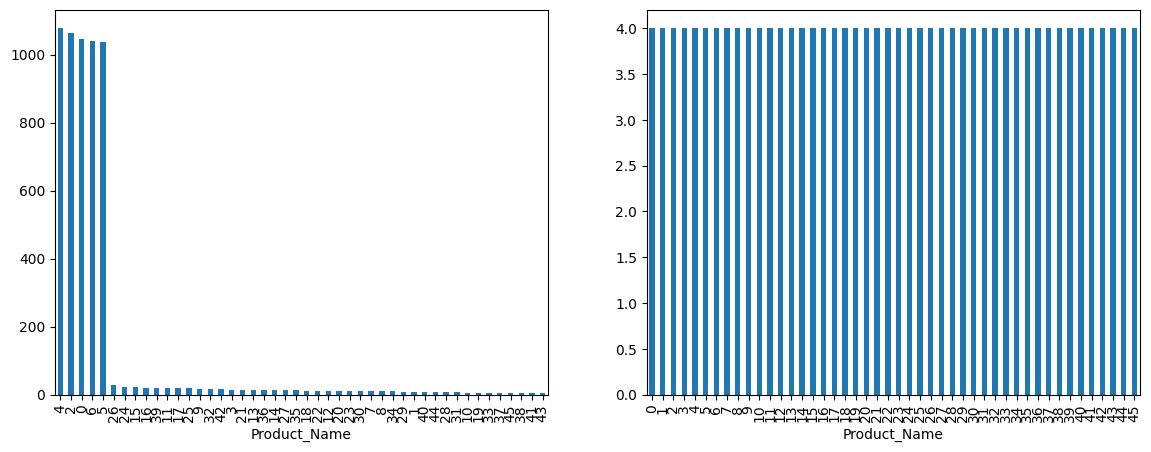

In [95]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
data['Product_Name'].value_counts().plot(kind='bar', ax=axes[0])
data_balanced['Product_Name'].value_counts().plot(kind='bar', ax=axes[1])

plt.show()

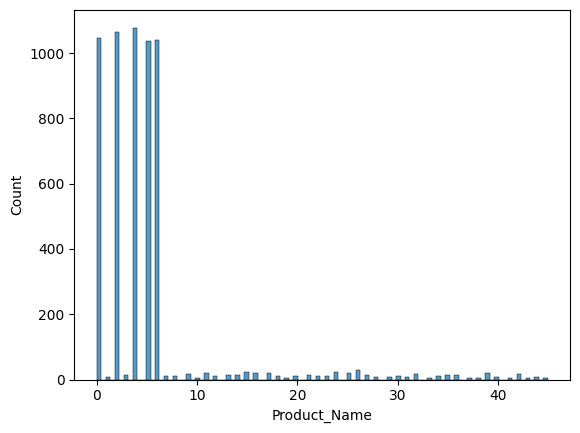

In [96]:
sns.histplot(data=data,x='Product_Name')

plt.show()

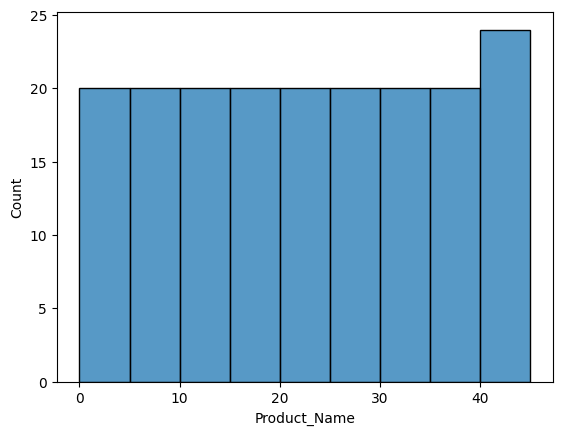

In [97]:
sns.histplot(data=data_balanced,x='Product_Name')

plt.show()